#**1. Eksperimen A/B Testing**



*   Tentukan desain eksperimen A/B testing untuk membuat
story telling data lebih mengalir (objektif, durasi,List item periode, dll)
*   Melakukan uji hipotesis untuk mendapatkan hasil konklusi A/B testing
*   Melakukan monitoring setelah A/B testing diimplementasikan













In [1]:
# Libary Import

import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.stats import shapiro, mannwhitneyu, ttest_ind
import statsmodels.stats.api as sms
from statsmodels.stats.power import NormalIndPower, TTestIndPower
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import matplotlib.pyplot as plt
import seaborn as sns

# Styling Visualization
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
np.random.seed(42)  # reproducibility

# Check if the library was imported successfully
print("Semua library berhasil di-import ✅")



Semua library berhasil di-import ✅


## Konteks Bisnis
Data yang digunakan adalah **spotify campaign data**. Saya menguji apakah penawaran **trial Premium selama 7 hari** (in-app-prompt) kepada user Free aktif dapat **meningkatkan conversion rate** (Free User ke **Subscription Premium**), tanpa menyebabkan penurunan signifikan pada rata-rata Duration Played.

### Step 1: Define the Goal
Meningkatkan conversion rate(primary metric) berlangganan (premium) tanpa mengurangi duration played (guardrail metric).

### Step 2: Form a Hypothesis
> "Jika kita menawarkan Trial Premium selama 7 Hari, maka conversion rate akan meningkat karena User Free telah merasakan manfaat dari Subscription Premium."

- **H0 (null hypothesis):** Tidak ada perbedaan conversion rate ke Premium antara Control dan Target (p_Control = p_Target) — penawaran trial Premium 7 hari tidak mengubah tingkat konversi Premium.

- **H1 (alternative hypothesis):** Ada perbedaan conversion rate ke Premium antara Control dan Target (p_Control ≠ p_Target) — two-tailed test.

### Step 3: Metrik
- **Primary metric:** Conversion Rate (Subscriptions Premium)
- **Guardrail metric:** Duration Played (jangan sampai turun signifikan)
- **Secondary metric:** Engagement Rate (untuk melihat apakah sejalan dengan naik/turunnya conversion rate)

---
## Step 4 : Sample Size & Power Analysis

Sebelum dilakukan eksperimen(campaign), ditetapkan dahulu sample size dan periode campaignnya.

## Konsep Kunci
| Konsep | Definisi | Nilai umum |
|---|---|---|
| **Significance Level (α)** | Probabilitas false positive (Type I Error) | 0.05 |
| **Statistical Power (1-β)** | Probabilitas mendeteksi efek yang benar-benar ada | ≥ 0.80 |
| **MDE** | Minimum Detectable Effect — efek terkecil yang ingin kita deteksi | tergantung bisnis |
| **Baseline Conversion** | Performa saat ini dari grup control | dari data historis |

**Rumus dari slide:**

n = (Z_α/2 + Z_β)² × 2σ² / δ²

Di mana δ = MDE (Minimum Detectable Effect)

>  **🔑:** Semakin kecil efek yang ingin kamu deteksi (MDE kecil), semakin besar sample size yang kamu butuhkan.

-----SAMPLE SIZE----
Baseline conversion rate        : 4.20%
MDE (relative)                  : 10.0%
Target conversion rate          : 4.62%
Effect size (Cohen's h)         : 0.0205
Significance level (α)          : 0.05
Statistical power (1-β)         : 0.8
Sample size dibutuhkan / grup   : 37,493 visitors
Total sample size (2 grup)      : 74,986 visitors

----- SENSITIVITAS: MDE vs SAMPLE SIZE -----
 MDE (%)  Target rate (%)  Cohen's h  n per grup  Total (2 grup)
     5.0            4.410     0.0103      146622          293244
     8.0            4.536     0.0164       58062          116124
    10.0            4.620     0.0205       37493           74986
    15.0            4.830     0.0304       17031           34062
    20.0            5.040     0.0401        9784           19568
    25.0            5.250     0.0496        6391           12782
    30.0            5.460     0.0589        4527            9054


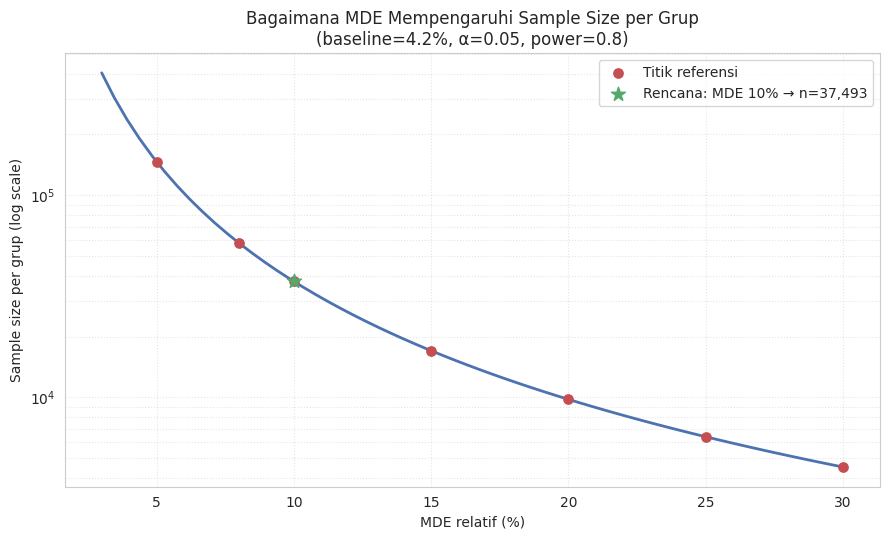

In [2]:
# MENENTUKAN SAMPLE SIZE dengan statmodels

# Parameter
baseline_rate        = 0.042   # baseline conversion rate historis
mde_relative_planned = 0.10    # MDE relatif yang ingin dideteksi (10%)
alpha                = 0.05
power_target         = 0.80

analysis = NormalIndPower()

# Effect size (Cohen's h)

def sample_size_for_mde(baseline_rate, mde_relative, alpha, power):
    """Hitung effect size (Cohen's h) & sample size per grup untuk 1 nilai MDE."""
    target_rate = baseline_rate * (1 + mde_relative)
    effect_size = sms.proportion_effectsize(baseline_rate, target_rate)
    n_per_group = analysis.solve_power(
        effect_size=abs(effect_size),
        alpha=alpha,
        power=power,
        ratio=1.0,
        alternative="two-sided")
    return target_rate, effect_size, int(np.ceil(n_per_group))


# Sample size untuk MDE yang direncanakan

target_rate_planned, effect_size_planned, n_required_per_group = sample_size_for_mde(
    baseline_rate, mde_relative_planned, alpha, power_target)

print("-----SAMPLE SIZE----")
print(f"Baseline conversion rate        : {baseline_rate*100:.2f}%")
print(f"MDE (relative)                  : {mde_relative_planned*100:.1f}%")
print(f"Target conversion rate          : {target_rate_planned*100:.2f}%")
print(f"Effect size (Cohen's h)         : {abs(effect_size_planned):.4f}")
print(f"Significance level (α)          : {alpha}")
print(f"Statistical power (1-β)         : {power_target}")
print(f"Sample size dibutuhkan / grup   : {n_required_per_group:,} visitors")
print(f"Total sample size (2 grup)      : {n_required_per_group*2:,} visitors")

# Bagaimana MDE mempengaruhi sample size

mde_list = [0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]

rows = []
for mde in mde_list:
    target_rate, eff_size, n_grup = sample_size_for_mde(baseline_rate, mde, alpha, power_target)
    rows.append({
        "MDE (%)": mde * 100,
        "Target rate (%)": round(target_rate * 100, 3),
        "Cohen's h": round(abs(eff_size), 4),
        "n per grup": n_grup,
        "Total (2 grup)": n_grup * 2
    })

df_sensitivity = pd.DataFrame(rows)
print("\n----- SENSITIVITAS: MDE vs SAMPLE SIZE -----")
print(df_sensitivity.to_string(index=False))

# Visualisasi: MDE vs Sample Size

mde_fine = np.linspace(0.03, 0.30, 60)
n_fine = [sample_size_for_mde(baseline_rate, m, alpha, power_target)[2] for m in mde_fine]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(mde_fine * 100, n_fine, color="#4C72B0", linewidth=2, zorder=2)
ax.scatter(df_sensitivity["MDE (%)"], df_sensitivity["n per grup"],
           color="#C44E52", zorder=3, s=45, label="Titik referensi")
ax.scatter([mde_relative_planned * 100], [n_required_per_group],
           color="#55A868", zorder=4, s=110, marker="*",
           label=f"Rencana: MDE {mde_relative_planned*100:.0f}% → n={n_required_per_group:,}")
ax.set_yscale("log")
ax.set_xlabel("MDE relatif (%)")
ax.set_ylabel("Sample size per grup (log scale)")
ax.set_title("Bagaimana MDE Mempengaruhi Sample Size per Grup\n"
             f"(baseline={baseline_rate*100:.1f}%, α={alpha}, power={power_target})")
ax.legend()
ax.grid(True, which="both", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


**Berdasarkan hasil** kalkulasi, dengan **baseline conversion rate 4.20%** dan **target MDE 10%** (relatif), **effect size** yang dihasilkan (Cohen's h = 0.0205), angka ini **tergolong sangat kecil** (jauh di bawah ambang small pada konvensi Cohen (0.2)). Untuk **mendeteksi perbedaan sekecil ini** dengan **power 80% pada alpha = 0.05**, dibuthkan **minimal sample 37,493** visitor setiap **grup** (74,986 visitor total).

Hal ini **sesuai dengan trade-off** klasik dalam A/B testing, **semakin kecil MDE** yang ingin dideteksi, semakin **besar effect size yang dibutuhkan**. Sehingga **durasi** pengumpulan data **juga akan lebih panjang** pada traffic yang sama.

## Step 5: Set Test Duration Berapa Lama Test Harus Berjalan?

Setelah tahu sample size dibutuhkan, dihitung estimasi **durasi test** berdasarkan histori traffic harian.

> ⚠️ **Aturan penting dari slide:** Test minimal dijalankan untuk **satu siklus bisnis penuh** (misal minimal 2 minggu / mencakup weekday & weekend) — jangan berhenti lebih awal walau hasil sudah kelihatan "signifikan"!

In [3]:
# RENCANA DURASI CAMPAIGN

daily_traffic_per_group = 400   # rata-rata visitor per grup per hari (historis ini diasumsikan)
min_business_cycle_days = 14    # minimal 1 siklus bisnis penuh (aturan dari slide)


def estimate_test_duration(n_required_per_group, daily_traffic_per_group, min_business_cycle_days=14):
    days_needed = int(np.ceil(n_required_per_group / daily_traffic_per_group))
    final_days = max(days_needed, min_business_cycle_days)
    return days_needed, final_days


days_math, days_final = estimate_test_duration(n_required_per_group, daily_traffic_per_group, min_business_cycle_days)

print("-----RENCANA DURATION TEST----")
print(f"Traffic harian / grup           : {daily_traffic_per_group:,} visitors")
print(f"Durasi minimum (dari hitungan)  : {days_math} hari")
print(f"Durasi final (business-cycle)   : {days_final} hari")

-----RENCANA DURATION TEST----
Traffic harian / grup           : 400 visitors
Durasi minimum (dari hitungan)  : 94 hari
Durasi final (business-cycle)   : 94 hari


Dengan histori rata rata 400 visitor per grup (agar total 74,986 visitor sesuai dengan rencana yang dibuat), dibutuhkan waktu ±94 hari.

**Telah dilakukan Campaign**, berdasarkan data Spotify Campaign dilakukan **Uji Hipotesis** dari **Converstion Rate** (Primary Matrics) serta dua matric lainnya, **Duration Play** (Guardrail Matric) dan **Engagement** (Secondary Matric).

In [4]:
# IMPORT DATA SPOTIFY CAMPAIGN
dfcamp = pd.read_excel('/content/Assignment - spotify_campaign_data.xlsx')
dfcamp.head()


,Group,Engagement,Duration Played,Payment,Subscription
0,Control,0.649671,122.946184,Yes,Premium
1,Control,0.586174,118.076753,Yes,Free
2,Control,0.664769,148.553723,Yes,Premium
3,Control,0.752303,165.984934,No,Premium
4,Control,0.576585,140.605408,Yes,Free


In [5]:
# INSPEKSI DATA SPOTIFY CAMPAIGN

dfcamp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Group            100000 non-null  object 
 1   Engagement       100000 non-null  float64
 2   Duration Played  100000 non-null  float64
 3   Payment          100000 non-null  object 
 4   Subscription     100000 non-null  object 
dtypes: float64(2), object(3)
memory usage: 3.8+ MB


In [6]:
#CHECK DUPLIKASI

# Jumlah baris yang duplikat
dfcamp.duplicated().sum()

# Lihat di bagian mana saja yang duplikat
# dfcamp[dfcamp.duplicated(keep=False)]


np.int64(0)

In [7]:
# DESKRIPSI DATA

dfcamp.describe()

,Engagement,Duration Played
count,100000.000000,100000.000000
mean,0.699842,139.991775
std,0.141362,36.040271
min,0.153440,-13.889056
25%,0.594898,115.065024
50%,0.699695,139.992180
75%,0.805039,165.020973
max,1.178219,286.580990


Dari describe terlihat min Duration Played -13.89, selanjutnya dilakukan inspeksi terhadap Duration Played

In [8]:
# Filter baris yang durasi played nya negatif
negative_duration = dfcamp[dfcamp['Duration Played'] < 0]

print(f"Jumlah baris dengan Duration Played negatif: {len(negative_duration)}")
print(negative_duration)



Jumlah baris dengan Duration Played negatif: 2
         Group  Engagement  Duration Played Payment Subscription
9759   Control    0.544888        -4.732016     Yes         Free
25586  Control    0.762011       -13.889056     Yes      Premium


Terdapat 2 duration played bernilai negatif di kelompok Control, tetapi hal ini dikemungkinan dikarenakan kesalahan teknis karena bernilai -4.7 menit dan -13.9 menit.

In [9]:
# Menghapus data duratin played yang negatif

dfcamp_clean = dfcamp[dfcamp['Duration Played'] >= 0].copy()

print(f"Sebelum drop: {len(dfcamp)} baris")
print(f"Setelah drop: {len(dfcamp_clean)} baris")

Sebelum drop: 100000 baris
Setelah drop: 99998 baris


Berdasarkan dfcamp.info() dan cek duplikasi, **tidak ada data yang duplikat maupun hilang**. Sehingga proses dapat dilanjutkan.

## Step 6. Uji Hipotesis - Conversion Rate (Primary Metric)

In [10]:
# RINGKASAN PER GRUP

dfcamp_clean["converted"] = (dfcamp_clean["Subscription"] == "Premium").astype(int)

summary = dfcamp_clean.groupby("Group")["converted"].agg(["count", "sum", "mean"])
summary.columns = ["n_visitors", "n_conversions", "conversion_rate"]
summary

,n_visitors,n_conversions,conversion_rate
Group,,,
Control,49998,29870,0.597424
Target,50000,40125,0.802500


Jika dibandingkan dengan jumlah **rencana sample (74.986 visitor)** dan durasi campaign **(94 hari, histori 400 visitor/grup)**, testing yang sudah dilakukan dengan total visitor 100.000, angka ini lebih besar dari target, sehingga sample bisa dikatakan mewakili populasi.

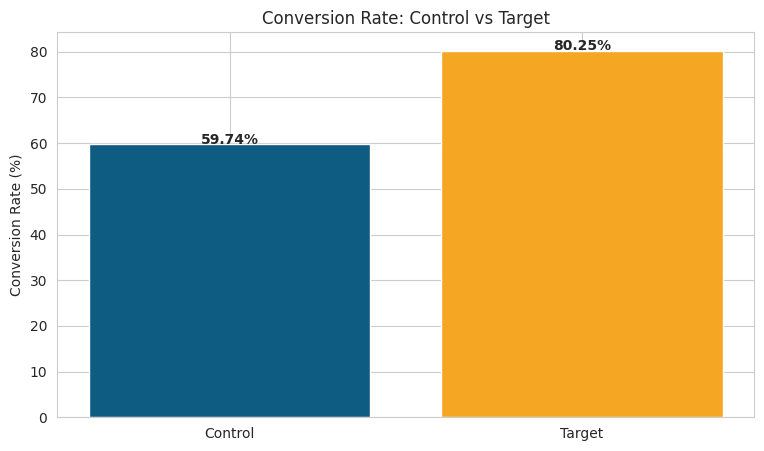

In [11]:
# VISUALISASI CONVERSION RATE PER GROUP

fig, ax = plt.subplots()
colors = ["#0F5C82", "#F5A623"]
bars = ax.bar(summary.index, summary["conversion_rate"] * 100, color=colors)
ax.set_ylabel("Conversion Rate (%)")
ax.set_title("Conversion Rate: Control vs Target")
for bar, val in zip(bars, summary["conversion_rate"] * 100):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05, f"{val:.2f}%", ha="center", fontweight="bold")
plt.show()

Berdasarkan visualisasi Conversion Rate (yang melakukan subscribe ke Premium), dapat dilihat bahwa **Target** (yang menggunakan Free Trial) memiliki **conversion rate** 80.25%, **20.51% lebih tinggi** dibanding **Control** (yang tidak menggunakan Free Trial) dengan **conversion rate 59.74%.**

Namun, perbedaan ini perlu **diuji signifikansinya secara statistik**, karena conversion rate saja tidak dapat memperlihatkan apakah perbedaan tersebut signifikan atau hanya kebetulan (random chance).

Selanjutnya, dilakukan Uji Hipotesis.

## Two-Proportion Z-Test

Karena metrik conversion rate adalah proporsi (subscribe Premium / tidak subscribe Premium), digunakan Two-Proportion Z-Test.

**H0 (null hypothesis):** Tidak ada perbedaan conversion rate antara Control dan Target (p_Control = p_Target)

**H1 (alternative hypothesis):** Ada perbedaan conversion rate antara Control dan Target (p_Control ≠ p_Target) — two-tailed test

alpha = 0.05

menggunakan `statsmodels`(cara praktis di lapangan)

In [12]:
# UJI HIPOTESIS TWO PROPORTION Z-TEST

# Angka dari ringkasan per Grup
count_control = summary.loc["Control", "n_conversions"]
nobs_control = summary.loc["Control", "n_visitors"]
count_target = summary.loc["Target", "n_conversions"]
nobs_target = summary.loc["Target", "n_visitors"]

# Menggunakan STATMODEL
count = np.array([count_target, count_control])
nobs = np.array([nobs_target, nobs_control])
z_stat_sm, p_value_sm = proportions_ztest(count, nobs, alternative="two-sided")

print("\n--- Dengan Statsmodels ---")
print(f"Z-statistic = {z_stat_sm:.4f}")
print(f"P-value = {p_value_sm:.10f}")

# Kesimpulan

print("\n--- Kesimpulan ---")
if p_value_sm < alpha:
    print(f"✅ SIGNIFICANT (p < {alpha}) — Tolak H0")
    print("Ada perbedaan conversion rate yang signifikan secara statistik antara Control dan Target.")
else:
    print(f"❌ NOT SIGNIFICANT (p >= {alpha}) — Gagal tolak H0")
    print("Belum cukup bukti perbedaan conversion rate signifikan antara Control dan Target.")


--- Dengan Statsmodels ---
Z-statistic = 70.7548
P-value = 0.0000000000

--- Kesimpulan ---
✅ SIGNIFICANT (p < 0.05) — Tolak H0
Ada perbedaan conversion rate yang signifikan secara statistik antara Control dan Target.


Berdasarkan uji Hipotesis ini P-value jauh lebih kecil dari alpha, sehingga **Tolak H0**. Berarti ada **perbedaan yang signifikan** secara statistik antara **conversion rate Control dan Target.**

## Confidence Interval & Effect Size

P-value saja **tidak cukup** untuk mengambil keputusan bisnis. Kita perlu tahu:
- **Confidence Interval (CI)** dari selisih conversion rate → seberapa besar rentang kemungkinan efek sebenarnya
- **Relative lift** → seberapa besar peningkatan dalam persen, supaya mudah dikomunikasikan ke stakeholder


--- Conversion Rate: Confidence Interval & Effect Size ---
95% CI Control : [59.31%, 60.17%]
95% CI Target  : [79.90%, 80.60%]

Selisih (Target - Control)        : 20.51 percentage points
95% CI selisih                    : [19.95%, 21.06%] (dalam pp)
Relative lift                     : 34.33%
CI mengandung 0?                  : Tidak (Signifikan)


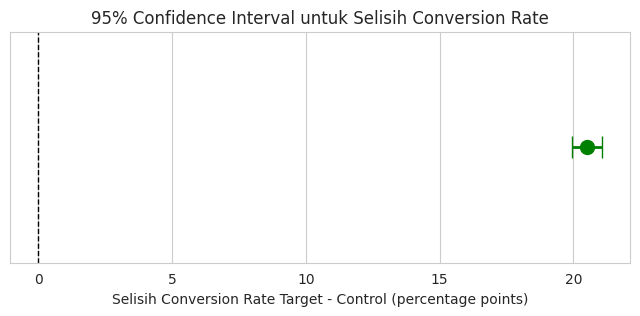

In [13]:
# CONFIDENCE INTERVAL & EFFECT SIZE

p_control = count_control / nobs_control
p_target = count_target / nobs_target

# Confidence Interval untuk masing-masing proporsi

ci_control = proportion_confint(count_control, nobs_control, alpha=0.05, method="normal")
ci_target = proportion_confint(count_target, nobs_target, alpha=0.05, method="normal")
print("--- Conversion Rate: Confidence Interval & Effect Size ---")
print(f"95% CI Control : [{ci_control[0]*100:.2f}%, {ci_control[1]*100:.2f}%]")
print(f"95% CI Target  : [{ci_target[0]*100:.2f}%, {ci_target[1]*100:.2f}%]")

# CI untuk SELISIH (difference) antara Target - Control

diff = p_target - p_control
se_diff = np.sqrt(p_control*(1-p_control)/nobs_control + p_target*(1-p_target)/nobs_target)
z_crit = stats.norm.ppf(0.975)

ci_diff_lower = diff - z_crit * se_diff
ci_diff_upper = diff + z_crit * se_diff
relative_lift = (p_target - p_control) / p_control * 100

print(f"\nSelisih (Target - Control)        : {diff*100:.2f} percentage points")
print(f"95% CI selisih                    : [{ci_diff_lower*100:.2f}%, {ci_diff_upper*100:.2f}%] (dalam pp)")
print(f"Relative lift                     : {relative_lift:.2f}%")
print(f"CI mengandung 0?                  : {'Ya (tidak signifikan)' if ci_diff_lower <= 0 <= ci_diff_upper else 'Tidak (Signifikan)'}")

# Visualisasi Confidence Interval

fig, ax = plt.subplots(figsize=(8, 3))
color = "green" if ci_diff_lower > 0 else ("red" if ci_diff_upper < 0 else "gray")
ax.errorbar(x=[diff*100], y=[0],
            xerr=[[diff*100 - ci_diff_lower*100], [ci_diff_upper*100 - diff*100]],
            fmt='o', color=color, markersize=10, capsize=8, linewidth=2)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_yticks([])
ax.set_xlabel("Selisih Conversion Rate Target - Control (percentage points)")
ax.set_title("95% Confidence Interval untuk Selisih Conversion Rate")
plt.show()

**Selisih Conversion rate** antara Target dan Control adalah **20.51** percentage points, dengan **95% Confidence Interval [19.95%, 21.06%]**. Karena rentang CI ini tidak mengandung angka 0, hasil ini mengkonfirmasi bahwa **perbedaannya** memang nyata, **bukan kebetulan**. Dan **relatif lift 34.33%** menandakan bahwa **conversion rate pada Target lebih baik** dari Control.

**Kesimpulan untuk Conversion Rate Control dan Target**

Berdasarkan hasil **Two-Proportion Z-Test**, didapatkan p-value yang jauh lebih kecil dari alpha (0.05), sehingga **H0 ditolak**. Artinya, **perbedaan** conversion rate antara Control dan Target **signifikan** secara statistik.

**Selisih conversion rate** antara Target dan Control adalah **20.51%**, dengan **95% Confidence Interval [19.95%, 21.06%]**. Karena rentang CI ini tidak mengandung angka 0, hasil ini mengkonfirmasi bahwa **perbedaannya** memang nyata, **bukan kebetulan**.

Selain itu, **penawaran trial Premium 7 hari meningkatkan conversion rate** secara relatif sebesar **34.33%** dibanding Control.

Selanjutnya dilakukan Uji Hipotesis untuk Guardrail Metric (Duration Played) dan secondary metric (Engagement), untuk menentukan manakah versi terbaik dari A(Control)/B(Target) Testing yang dilakukan.

## Step 7: Uji Hipotesis — Duration Played (Guardrail Metric)

Karena metrik kita adalah data kontinu (durasi dalam menit), dilakukan dulu cek normalitas datanya dengan Shapiro-Wilk. Jika normal, gunakan T-Test untuk uji hipotesisnya. Jika tidak normal, gunakan Mann-Whitney U Test.

**H0 (null hypothesis):** Tidak ada perbedaan rata-rata Duration Played antara Control dan Target (μ_Control = μ_Target)

**H1 (alternative hypothesis):** Ada perbedaan rata-rata Duration Played antara Control dan Target (μ_Control ≠ μ_Target) — two-tailed test

alpha = 0.05

--- Uji Normalitas (Shapiro-Wilk) ---
Control : statistic=1.0000, p-value=0.8389879103
Target  : statistic=1.0000, p-value=0.8340457265
Control: Terdistribusi normal (p > 0.05)
Target : Terdistribusi normal (p > 0.05)


/usr/local/lib/python3.13/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 49998.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.13/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 50000.
  res = hypotest_fun_out(*samples, **kwds)
/tmp/ipykernel_491/1060880322.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Group", y="Duration Played", data=dfcamp, palette=colors, ax=axes[1])


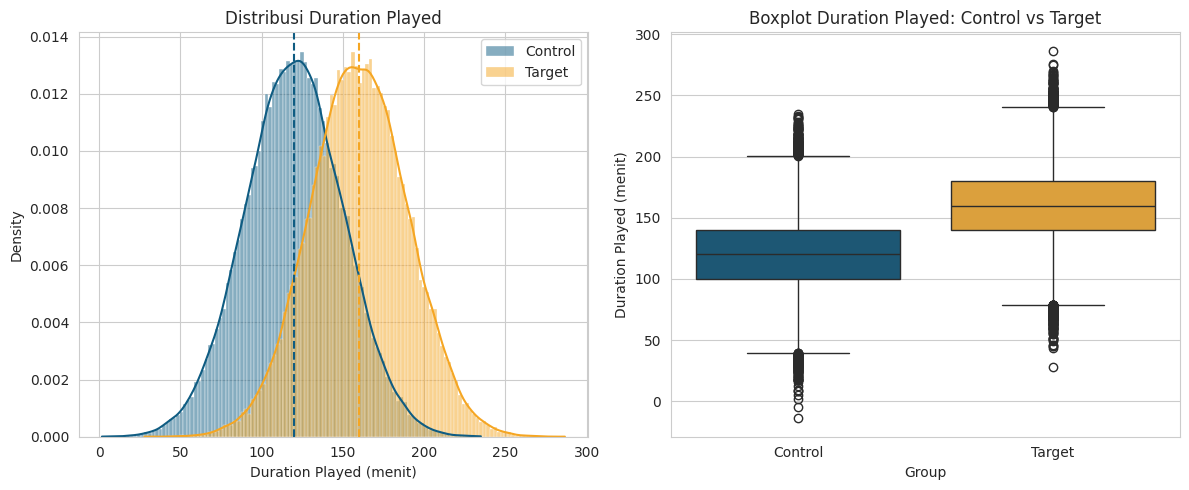

In [14]:
# DURATION PLAYED (Guadrail Metric)

# Berdasarkan data per grup

control_duration = dfcamp_clean[dfcamp_clean["Group"] == "Control"]["Duration Played"]
target_duration = dfcamp_clean[dfcamp_clean["Group"] == "Target"]["Duration Played"]
mean_control_dur = control_duration.mean()
mean_target_dur = target_duration.mean()

# Uji Normalitas (Shapiro-Wilk)

stat_c, p_c = shapiro(control_duration)
stat_t, p_t = shapiro(target_duration)

print("--- Uji Normalitas (Shapiro-Wilk) ---")
print(f"Control : statistic={stat_c:.4f}, p-value={p_c:.10f}")
print(f"Target  : statistic={stat_t:.4f}, p-value={p_t:.10f}")


normal_control = p_c > alpha
normal_target = p_t > alpha
print("Control:", "Terdistribusi normal (p > 0.05)" if normal_control else "TIDAK terdistribusi normal (p <= 0.05)")
print("Target :", "Terdistribusi normal (p > 0.05)" if normal_target else "TIDAK terdistribusi normal (p <= 0.05)")

# Visualisasi Sebaran Duration Played
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = {"Control": "#0F5C82", "Target": "#F5A623"}
0
sns.histplot(control_duration, color=colors["Control"], label="Control", kde=True, stat="density", alpha=0.5, ax=axes[0])
sns.histplot(target_duration, color=colors["Target"], label="Target", kde=True, stat="density", alpha=0.5, ax=axes[0])
axes[0].axvline(mean_control_dur, color=colors["Control"], linestyle="--", linewidth=1.5)
axes[0].axvline(mean_target_dur, color=colors["Target"], linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Duration Played (menit)")
axes[0].set_title("Distribusi Duration Played")
axes[0].legend()

sns.boxplot(x="Group", y="Duration Played", data=dfcamp, palette=colors, ax=axes[1])
axes[1].set_title("Boxplot Duration Played: Control vs Target")
axes[1].set_ylabel("Duration Played (menit)")
plt.tight_layout()
plt.show()

Berdasarkan hasil uji **Shapiro-Wilk**, diketahui **Duration Play** Control dan Target sama sama **terdistribusi normal**. Sehingga dapat dilakukan t-test untuk uji hipotesisnya.

##T-test (two tailed)

Dilanjutkan dengan uji T-Test (two_tailed).

In [15]:
# T-Test (two-tailed, default di scipy)

t_stat, p_value = ttest_ind(control_duration, target_duration)

print("--- T-Test ---")
print(f"T-statistic = {t_stat:.4f}")
print(f"P-value = {p_value:.10f}")

print(f"\nRata-rata Duration Played Control : {control_duration.mean():.2f} menit")
print(f"Rata-rata Duration Played Target  : {target_duration.mean():.2f} menit")

# Kesimpulan

alpha = 0.05
print("\n--- Kesimpulan ---")
if p_value < alpha:
    print(f"✅ SIGNIFICANT (p < {alpha}) — Tolak H0")
    print("Ada perbedaan Duration Played yang signifikan secara statistik antara Control dan Target.")
else:
    print(f"❌ NOT SIGNIFICANT (p >= {alpha}) — Gagal tolak H0")
    print("Tidak ada perbedaan Duration Played yang signifikan — guardrail metric AMAN.")

--- T-Test ---
T-statistic = -209.7555
P-value = 0.0000000000

Rata-rata Duration Played Control : 120.08 menit
Rata-rata Duration Played Target  : 159.91 menit

--- Kesimpulan ---
✅ SIGNIFICANT (p < 0.05) — Tolak H0
Ada perbedaan Duration Played yang signifikan secara statistik antara Control dan Target.


Berdasarkan **hasil uji T-Test**, menunjukkan p-value jauh lebih kecil dari alpha (0.05), sehingga **H0 ditolak**. Berarti ada **perbedaan Duration Played yang signifikan** antara Control dan Target.

## Confidence Interval & Effect Size

P-value saja **tidak cukup** untuk mengambil keputusan bisnis. Perlu diketahui:
- **Confidence Interval (CI)** dari selisih conversion rate → seberapa besar rentang kemungkinan efek sebenarnya
- **Relative lift** → seberapa besar peningkatan dalam persen, supaya mudah dikomunikasikan ke stakeholder

--- Duration Played: Confidence Interval & Effect Size ---
95% CI Control : [119.81, 120.34] menit
95% CI Target  : [159.65, 160.18] menit

Selisih (Target - Control)                      : 39.84 menit
Relatif Lift                                    : 33.18% 
95% CI selisih (menit)                          : [39.46, 40.21] menit
95% CI selisih (persen)                         : [32.87%, 33.49%]
CI mengandung 0?                                : Tidak (Signifikan)


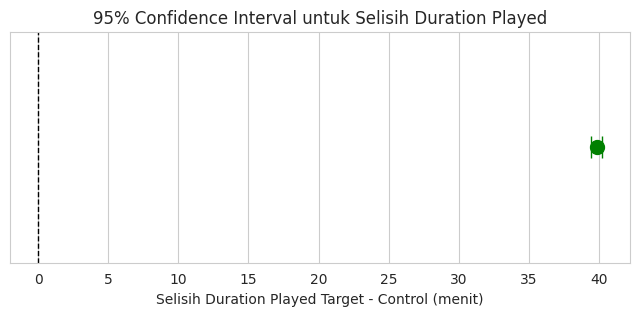

In [16]:
# Duration Played Confidence Interval & Effect Size

n_control_dur = len(control_duration)
n_target_dur = len(target_duration)
var_control_dur = control_duration.var(ddof=1)
var_target_dur = target_duration.var(ddof=1)

# Confidence Interval untuk masing-masing proporsi

se_control_dur = np.sqrt(var_control_dur / n_control_dur)
se_target_dur = np.sqrt(var_target_dur / n_target_dur)
ci_control_dur = stats.t.interval(0.95, df=n_control_dur-1, loc=mean_control_dur, scale=se_control_dur)
ci_target_dur = stats.t.interval(0.95, df=n_target_dur-1, loc=mean_target_dur, scale=se_target_dur)

print("--- Duration Played: Confidence Interval & Effect Size ---")
print(f"95% CI Control : [{ci_control_dur[0]:.2f}, {ci_control_dur[1]:.2f}] menit")
print(f"95% CI Target  : [{ci_target_dur[0]:.2f}, {ci_target_dur[1]:.2f}] menit")

# CI untuk SELISIH (difference) antara Target - Control ( Welch CI utk estimasi selisih)

diff_dur = mean_target_dur - mean_control_dur
se_diff_dur = np.sqrt(var_control_dur/n_control_dur + var_target_dur/n_target_dur)
df_welch_dur = (var_control_dur/n_control_dur + var_target_dur/n_target_dur)**2 / (
    (var_control_dur/n_control_dur)**2/(n_control_dur-1) + (var_target_dur/n_target_dur)**2/(n_target_dur-1)
)
t_crit_dur = stats.t.ppf(0.975, df_welch_dur)

ci_diff_lower_dur = diff_dur - t_crit_dur * se_diff_dur
ci_diff_upper_dur = diff_dur + t_crit_dur * se_diff_dur
relative_lift_dur = (mean_target_dur - mean_control_dur) / mean_control_dur * 100
ci_diff_lower_dur_pct = (ci_diff_lower_dur / mean_control_dur) * 100
ci_diff_upper_dur_pct = (ci_diff_upper_dur / mean_control_dur) * 100

print(f"\nSelisih (Target - Control)                      : {diff_dur:.2f} menit")
print(f"Relatif Lift                                    : {relative_lift_dur:.2f}% ")
print(f"95% CI selisih (menit)                          : [{ci_diff_lower_dur:.2f}, {ci_diff_upper_dur:.2f}] menit")
print(f"95% CI selisih (persen)                         : [{ci_diff_lower_dur_pct:.2f}%, {ci_diff_upper_dur_pct:.2f}%]")
print(f"CI mengandung 0?                                : {'Ya (tidak signifikan)' if ci_diff_lower_dur <= 0 <= ci_diff_upper_dur else 'Tidak (Signifikan)'}")

# Visualisasi Confident Interval

fig, ax = plt.subplots(figsize=(8, 3))
color = "green" if ci_diff_lower_dur > 0 else ("red" if ci_diff_upper_dur < 0 else "gray")
ax.errorbar(x=[diff_dur], y=[0],
            xerr=[[diff_dur - ci_diff_lower_dur], [ci_diff_upper_dur - diff_dur]],
            fmt='o', color=color, markersize=10, capsize=8, linewidth=2)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_yticks([])
ax.set_xlabel("Selisih Duration Played Target - Control (menit)")
ax.set_title("95% Confidence Interval untuk Selisih Duration Played")
plt.show()

**Selisih Duration Play** antara **Target dan Control** adalah **39.84 menit**, atau setara dengan **33.18%** lebih tinggi secara relatif dibandingkan Control, dengan **95% Confidence Interval [32.87%, 33.49%]**. Karena rentang CI ini tidak mengandung angka 0, hasil ini **mengkonfirmasi** bahwa **perbedaannya** memang nyata, **bukan kebetulan**. Dan **relatif lift 33.18%** menandakan bahwa **duration Play pada Target lebih baik** dari Control.

**Kesimpulan untuk Duration Play**

Berdasarkan **hasil uji T-Test**, menunjukkan p-value jauh lebih kecil dari alpha (0.05), sehingga **H0 ditolak**. Berarti ada **perbedaan Duration Played** yang **signifikan antara Control dan Target**.

Serta **95% Confidence Interval [32.87%, 33.49%]**. Karena rentang CI ini tidak mengandung angka 0, hasil ini **mengkonfirmasi** bahwa **perbedaannya** memang nyata, **bukan kebetulan**.

Kesimpulan ini juga **diperkuat** oleh **rata-rata Duration Played Target** (159.91 menit) **lebih tinggi 39.84 menit** dibandingkan Control (120.07 menit), atau setara **peningkatan relatif sebesar 33.18%**.


## Step 8: Uji Hipotesis — Engagement (Secondary Metric)

Sama seperti Duration Played, Engagement juga data kontinu, jadi dicek dulu normalitasnya dengan Shapiro-Wilk sebelum pilih T-Test atau Mann-Whitney U Test.

**H0 (null hypothesis):** Tidak ada perbedaan rata-rata Engagement antara Control dan Target (μ_Control = μ_Target)

**H1 (alternative hypothesis):** Ada perbedaan rata-rata Engagement antara Control dan Target (μ_Control ≠ μ_Target) — two-tailed test

alpha = 0.05

--- Uji Normalitas (Shapiro-Wilk) ---
Control : statistic=1.0000, p-value=0.9916238675
Target  : statistic=1.0000, p-value=0.7561068125
Control: Terdistribusi normal (p > 0.05)
Target : Terdistribusi normal (p > 0.05)


/usr/local/lib/python3.13/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 49998.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.13/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 50000.
  res = hypotest_fun_out(*samples, **kwds)
/tmp/ipykernel_491/3767310703.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Group", y="Engagement", data=dfcamp, palette=colors, ax=axes[1])


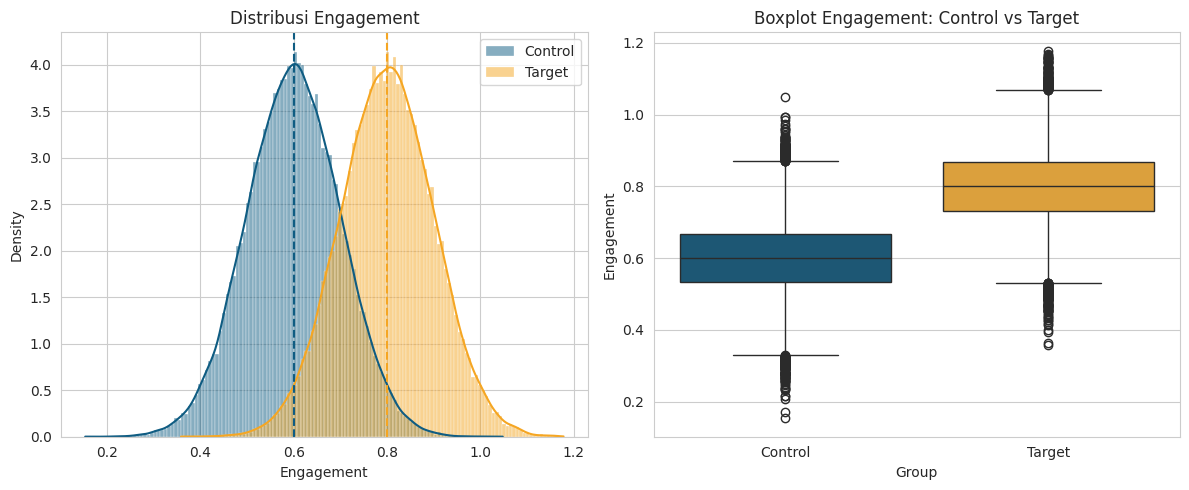

In [17]:
# ENGAGEMENT (Secondary Metric)

# Berdasarkan data per grup

control_engagement = dfcamp_clean[dfcamp_clean["Group"] == "Control"]["Engagement"]
target_engagement = dfcamp_clean[dfcamp_clean["Group"] == "Target"]["Engagement"]
mean_control_eng = control_engagement.mean()
mean_target_eng = target_engagement.mean()

# Uji Normalitas (Shapiro-Wilk)

stat_c, p_c = shapiro(control_engagement)
stat_t, p_t = shapiro(target_engagement)

print("--- Uji Normalitas (Shapiro-Wilk) ---")
print(f"Control : statistic={stat_c:.4f}, p-value={p_c:.10f}")
print(f"Target  : statistic={stat_t:.4f}, p-value={p_t:.10f}")

normal_control_eng = p_c > alpha
normal_target_eng = p_t > alpha
print("Control:", "Terdistribusi normal (p > 0.05)" if normal_control_eng else "TIDAK terdistribusi normal (p <= 0.05)")
print("Target :", "Terdistribusi normal (p > 0.05)" if normal_target_eng else "TIDAK terdistribusi normal (p <= 0.05)")

# Visualisasi Sebaran Engegement

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = {"Control": "#0F5C82", "Target": "#F5A623"}

sns.histplot(control_engagement, color=colors["Control"], label="Control", kde=True, stat="density", alpha=0.5, ax=axes[0])
sns.histplot(target_engagement, color=colors["Target"], label="Target", kde=True, stat="density", alpha=0.5, ax=axes[0])
axes[0].axvline(mean_control_eng, color=colors["Control"], linestyle="--", linewidth=1.5)
axes[0].axvline(mean_target_eng, color=colors["Target"], linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Engagement")
axes[0].set_title("Distribusi Engagement")
axes[0].legend()

sns.boxplot(x="Group", y="Engagement", data=dfcamp, palette=colors, ax=axes[1])
axes[1].set_title("Boxplot Engagement: Control vs Target")
axes[1].set_ylabel("Engagement")
plt.tight_layout()
plt.show()

Berdasarkan **hasil uji Shapiro-Wilk**, diketahui Engagement Control dan Target sama sama **terdistribusi normal**. Sehingga dapat dilakukan **t-test** untuk uji hipotesisnya.

##T-test (two tailed)

Berdasarkan hasil Uji Normalitas, Engagement Control dan Target terdistribusi Normal, sehingga dapat dilanjutkan dengan uji T-Test

In [18]:
# T-Test (two-tailed, default di scipy)

t_stat, p_value = ttest_ind(control_engagement, target_engagement)

print("--- T-Test ---")
print(f"Statistic = {t_stat:.4f}")
print(f"P-value = {p_value:.10f}")
print(f"\nRata-rata Engagement Control : {control_engagement.mean():.4f}")
print(f"Rata-rata Engagement Target  : {target_engagement.mean():.4f}")

# Kesimpulan

print("\n--- Kesimpulan ---")
if p_value < alpha:
    print(f"✅ SIGNIFICANT (p < {alpha}) — Tolak H0")
    print("Ada perbedaan Engagement yang signifikan secara statistik antara Control dan Target.")
else:
    print(f"❌ NOT SIGNIFICANT (p >= {alpha}) — Gagal tolak H0")
    print("Tidak ada perbedaan Engagement yang signifikan secara statistik antara Control dan Target.")

--- T-Test ---
Statistic = -315.7634
P-value = 0.0000000000

Rata-rata Engagement Control : 0.6000
Rata-rata Engagement Target  : 0.7997

--- Kesimpulan ---
✅ SIGNIFICANT (p < 0.05) — Tolak H0
Ada perbedaan Engagement yang signifikan secara statistik antara Control dan Target.


Berdasarkan **hasil uji T-Test**, menunjukkan p-value jauh lebih kecil dari alpha (0.05), sehingga **H0 ditolak**. Berarti ada **perbedaan Engagement** yang **signifikan** antara Control dan Target.

## Confidence Interval & Effect Size

P-value saja **tidak cukup** untuk mengambil keputusan bisnis. Perlu diketahu:
- **Confidence Interval (CI)** dari selisih conversion rate → seberapa besar rentang kemungkinan efek sebenarnya
- **Relative lift** → seberapa besar peningkatan dalam persen, supaya mudah dikomunikasikan ke stakeholder

--- Engagement: Confidence Interval & Effect Size ---
95% CI Control : [59.91%, 60.08%]
95% CI Target  : [79.88%, 80.06%]

Selisih (Target - Control)        : 19.98 percentage points
95% CI selisih                    : [19.85%, 20.10%]
Relative lift                     : 33.30%
CI mengandung 0?                  : Tidak (Signifikan)


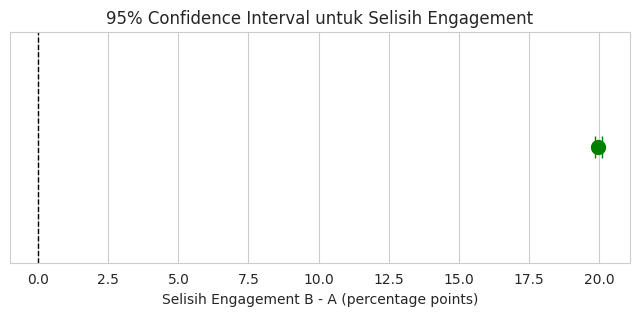

In [19]:
# Confidence Interval & Effect Size

n_control_eng = len(control_engagement)
n_target_eng = len(target_engagement)
var_control_eng = control_engagement.var(ddof=1)
var_target_eng = target_engagement.var(ddof=1)

# Confidence Interval untuk masing-masing proporsi

se_control_eng = np.sqrt(var_control_eng / n_control_eng)
se_target_eng = np.sqrt(var_target_eng / n_target_eng)
ci_control_eng = stats.t.interval(0.95, df=n_control_eng-1, loc=mean_control_eng, scale=se_control_eng)
ci_target_eng = stats.t.interval(0.95, df=n_target_eng-1, loc=mean_target_eng, scale=se_target_eng)

print("--- Engagement: Confidence Interval & Effect Size ---")
print(f"95% CI Control : [{ci_control_eng[0]*100:.2f}%, {ci_control_eng[1]*100:.2f}%]")
print(f"95% CI Target  : [{ci_target_eng[0]*100:.2f}%, {ci_target_eng[1]*100:.2f}%]")

# CI untuk SELISIH (difference) antara Target - Control

diff_eng = mean_target_eng - mean_control_eng
se_diff_eng = np.sqrt(var_control_eng/n_control_eng + var_target_eng/n_target_eng)
df_welch_eng = (var_control_eng/n_control_eng + var_target_eng/n_target_eng)**2 / (
    (var_control_eng/n_control_eng)**2/(n_control_eng-1) + (var_target_eng/n_target_eng)**2/(n_target_eng-1)
)
t_crit_eng = stats.t.ppf(0.975, df_welch_eng)

ci_diff_lower_eng = diff_eng - t_crit_eng * se_diff_eng
ci_diff_upper_eng = diff_eng + t_crit_eng * se_diff_eng
relative_lift_eng = (mean_target_eng - mean_control_eng) / mean_control_eng * 100

print(f"\nSelisih (Target - Control)        : {diff_eng*100:.2f} percentage points")
print(f"95% CI selisih                    : [{ci_diff_lower_eng*100:.2f}%, {ci_diff_upper_eng*100:.2f}%]")
print(f"Relative lift                     : {relative_lift_eng:.2f}%")
print(f"CI mengandung 0?                  : {'Ya (tidak signifikan)' if ci_diff_lower_eng <= 0 <= ci_diff_upper_eng else 'Tidak (Signifikan)'}")

# Visualisasi Confidence Interval

fig, ax = plt.subplots(figsize=(8, 3))
color = "green" if ci_diff_lower_eng > 0 else ("red" if ci_diff_upper_eng < 0 else "gray")
ax.errorbar(x=[diff_eng*100], y=[0],
            xerr=[[diff_eng*100 - ci_diff_lower_eng*100], [ci_diff_upper_eng*100 - diff_eng*100]],
            fmt='o', color=color, markersize=10, capsize=8, linewidth=2)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_yticks([])
ax.set_xlabel("Selisih Engagement B - A (percentage points)")
ax.set_title("95% Confidence Interval untuk Selisih Engagement")
plt.show()

**Selisih Engagement** antara **Target dan Control** adalah **19.98%**, Target lebih tinggi secara relatif dibandingkan Control, dengan **95% Confidence Interval [19.85%, 20.10%]**. Karena rentang CI ini tidak mengandung angka 0, hasil ini **mengkonfirmasi** bahwa **perbedaannya** memang nyata, **bukan kebetulan**. Dan relatif **lift 33.30%** menandakan bahwa **Engagement pada Target lebih** baik dari Control.

**Kesimpulan untuk Engagement**

Berdasarkan **hasil uji T-Test**, menunjukkan p-value jauh lebih kecil dari alpha (0.05), sehingga **H0 ditolak**. Berarti **ada perbedaan** Engagement yang **signifikan** antara Control dan Target.

Serta **95% Confidence Interval [19.85%, 20.10%]**. Karena rentang CI ini tidak mengandung angka 0, hasil ini **mengkonfirmasi** bahwa **perbedaannya** memang nyata, **bukan kebetulan**.

Kesimpulan ini juga **diperkuat** oleh **relatif lift 33.30%** menandakan bahwa **Engagement pada Target lebih baik** dari Control.

**Kesimpulan Keseluruhan**

Setelah dilakukan **uji terhadap ketiga metric** (Conversion Rate, Duration Played dan Engagament) , hasilnya **sama sama menunjukan perbedaan yang signifikan** secara statistik **antara Control dan Target**, dan ketiganya **konsisten (Target lebih baik dari Control)**.

Dengan **Relatif Lift** Conversion Rate 34.33%, Duration Played 33.18% dan Engagement 33.30%, angka ini cukup dekat **berkisar antara (33-34%)**, menunjukkan bahwa **dampak Free Trial 7 hari ini merata**, bukan hanya mendongkrak satu metrik.

#**2. Recommendation & Insight from Analysis**

*   Berikan  rekomendasi strategis berdasarkan hasil A/B Testing
*   Melakukan kesimpulan terhadap hasil monitoring before vs after setelah A/B Testing dilakukan







**Insight**

**Free Trail 7 hari terbukti efektif**, bukan hanya meningkatkann jumlah subscriber Premium (conversion rate), tetapi user juga lebih engeged dan menghabiskan waktu lebih lama menggunakan aplikasi, bukan hanya "mencoba gratis lalu pergi"


**Tidak ada trade-off negatif yang terlihat**, sering kali jika dilakukan strategi akuisisi agresif (seperti trial gratis) menarik user berkualitas rendah yang hanya memanfaatkan promo. Sementara Duration Played dan Engagement naik, hal ini mengindikasikan kualitas user Target tidak lebih buruk, bahkan lebih baik.


**Hasil ini reliable (dapat dipercaya) secara statistik,** jumlah visitor aktual selama testing (100,000) jauh lebih tinggi dari kebutuhan minimum yang direncanakan (74,986), menghasilkan Confidance Interfal yang cukup sempit di ketiga metrik. Hal ini meyakinkan angka-angka yang dihasilkn bukan kebetulan.

**Rekomendasi**

**Meluncurankan Free Trial 7 hari ke seluruh user** (bukan hanya grup Target), karena hasil uji sudah signifikan dan konsisten pada ketiga metrik.

**Memonitor setelah masa trial berakhir**, karena data hanya menggambarkan perilaku user selama periode trial (15 hari campaign). Maka perlu dipantau lebih lanjut apakah engagement dan duration play tetap tinggi meski trial sudah berakhir (apakah ada risiko churn pasca-trial)

**Melakukan analisis biaya vs manfaat**, trial gratis berarti menunda revenue (7 hari tanpa pembayaran). Hal ini perlu diperhitungkan apakah kenaikan conversion rate 34% ini cukup untuk menutup biaya akuisisi selama trial tersebut.

**Mempertimbangkan segmentasi lanjutan**, apakah efek Free Trial ini sama kuatnya di semua segmen user (baru vs lama), untuk melihat apakah ada segmen tertentu yang memberi respons jauh lebih tinggi/rendah dari rata-rata.


##POST IMPLEMENTATION

Seletah Dilakukan IMPLEMENTASI berdasarkan hasil campaign, berikut data yang diperoleh selama 15 hari Implementasi (data dari AB TEST Post Implement)

In [20]:
# JUMLAH USER SELAMA 15 HARI SETELAH IMPLEMENTASI
dfpost = pd.read_excel('/content/Assignment - AB Test - Post Implement.xlsx')
dfpost.head()

,Date,Total Users
0,2026-03-01,19304
1,2026-03-02,16799
2,2026-03-03,13986
3,2026-03-04,15981
4,2026-03-05,18390


In [21]:
dfpost.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         15 non-null     datetime64[ns]
 1   Total Users  15 non-null     int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 372.0 bytes


In [22]:
dfpost.duplicated().sum()

np.int64(0)

In [23]:
# DURASI SETELAH IMPLEMENTASI

dfpost["Date"] = pd.to_datetime(dfpost["Date"])
tanggal_mulai = dfpost["Date"].min()
tanggal_selesai = dfpost["Date"].max()
durasi_aktual_hari = (tanggal_selesai - tanggal_mulai).days + 1  # +1 karena inklusif

total_visitor_aktual = dfpost["Total Users"].sum()
rata2_visitor_harian = dfpost["Total Users"].mean()

print("---DURASI & VOLUME SETELAH CAMPAIGN (Post Implement)---")
print(f"Tanggal mulai                 : {tanggal_mulai.date()}")
print(f"Tanggal selesai                : {tanggal_selesai.date()}")
print(f"Durasi testing aktual           : {durasi_aktual_hari} hari")
print(f"Total visitor selama testing    : {total_visitor_aktual:,}")
print(f"Rata-rata visitor / hari        : {rata2_visitor_harian:,.0f}")

---DURASI & VOLUME SETELAH CAMPAIGN (Post Implement)---
Tanggal mulai                 : 2026-03-01
Tanggal selesai                : 2026-03-15
Durasi testing aktual           : 15 hari
Total visitor selama testing    : 310,423
Rata-rata visitor / hari        : 20,695


In [24]:
dfpost['Date'] = pd.to_datetime(dfpost['Date'])
dfpost = dfpost.sort_values('Date').reset_index(drop=True)

# Dibagi menjadi minggu 1 (hari 1-7) dan minggu 2 (hari 8-15)
week1 = dfpost.iloc[:7]
week2 = dfpost.iloc[7:]

avg1 = week1['Total Users'].mean()
avg2 = week2['Total Users'].mean()
growth_pct = (avg2 - avg1) / avg1 * 100

print(f"Avg hari 1-7   : {avg1:,.1f}")
print(f"Avg hari 8-15  : {avg2:,.1f}")
print(f"Growth minggu2 vs minggu1: {growth_pct:.1f}%")

# Tren garis (linear regression slope)

x = np.arange(1, len(dfpost) + 1)
y = dfpost['Total Users'].values
slope, intercept = np.polyfit(x, y, 1)

print(f"Slope (rata-rata kenaikan user per hari): {slope:,.1f}")

# Growth dari hari pertama ke hari terakhir
first_val = dfpost['Total Users'].iloc[0]
last_val = dfpost['Total Users'].iloc[-1]
growth_first_last = (last_val - first_val) / first_val * 100

print(f"Total Users hari 1  : {first_val:,}")
print(f"Total Users hari 15 : {last_val:,}")
print(f"Growth hari1 -> hari15: {growth_first_last:.1f}%")

Avg hari 1-7   : 16,184.1
Avg hari 8-15  : 24,641.8
Growth minggu2 vs minggu1: 52.3%
Slope (rata-rata kenaikan user per hari): 871.1
Total Users hari 1  : 19,304
Total Users hari 15 : 24,446
Growth hari1 -> hari15: 26.6%


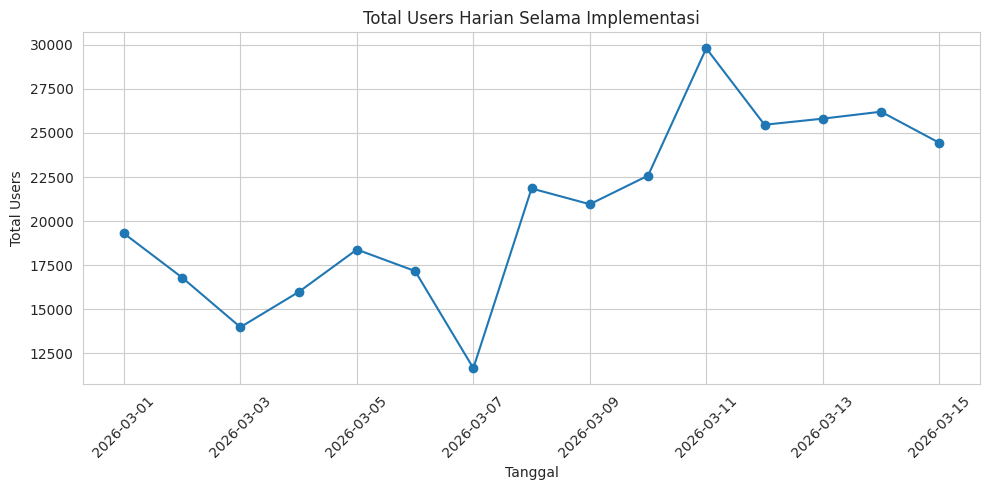

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(dfpost['Date'], dfpost['Total Users'], marker='o')
plt.title('Total Users Harian Selama Implementasi')
plt.xlabel('Tanggal')
plt.ylabel('Total Users')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Setelah implementasi dilakukan**

**Tren user fluktuatif tetapi tumbuh positif**. Total Users hari pertama 19,304 dan Total Users hari ke-15 yaitu 24,446. Berdasarkan rata-rata user naik dari sekitar 16.000/hari (minggu 1) menjadi sekitar 24.000/hari (minggu 2), growth sekitar 52%, dengan slope tren naik 871 user/hari. Hasil ini searah dengan A(Control)/B(Target) test yang menunjukkan Free Trial efektif meningkatkan engagement.

**Tidak ada tanda dampak negatif** . Biasanya yang terjadi di lapanngan, tren naik sebentar lalu turun (spike-and-drop). Di sini trennya justru makin kuat di minggu kedua, jadi indikasinya user memang engaged, bukan sekadar mampir gratis lalu pergi.

Namun masih ada **beberapa hal yang belum bisa dipastikan**, kenaikan ini belum tentu murni efek campaign (tidak ada data sebelum campaign sebagai pembanding), Total Users juga belum tentu sama dengan conversion rate ke Premium, dan belum terlihat apakah user tetap aktif setelah masa trial berakhir.

**Kesimpulan**, implementasi Campaign berhasil mendorong pertumbuhan user secara nyata selama masa pemantauan, sejalan dengan prediksi A/B test. Tetapi untuk memastikan efeknya murni dari campaign dan berdampak ke revenue, masih perlu data tambahan, seperti baseline sebelum campaign, conversion rate ke Premium, dan retensi pasca-trial.

#**3. Reflection Questions**

*   **Mengapa perancangan detail terkait eksperimen A/B testing seperti penentuan lama A/B testing, pemilihan sampel, dan lainnya, sangat krusial pada hasil eksperimen?**

Karena detail perancangan akan menentukan apakah hasil eksperimen/campaign dapat dipercaya atau tidak. Jika pemilihan sampel tidak sesuai (sedikit), hasil eksperimen sangat kurang dipercaya karena power-nya rendah, jadi berkemungkinan gagal mendeteksi perbedaan yang sebenarnya ada, bukan cuma soal tidak mewakili populasi. Sedangkan jika periodenya tidak sesuai (terlalu pendek), hasil campaign bisa bias karena belum menangkap variasi siklus bisnis, misalnya beda perilaku weekday vs weekend.


*  **Apa yang akan dilakukan jika ternyata kondisi current lebih baik daripada kondisi inovasi?**

Jika kondisi current (Control) lebih baik dibandingkan inovasi (Target) secara signifikan, sebaiknya tidak buru-buru meluncurkan inovasi tersebut. Setelah itu dapat dilakukan investigasi, apakah ada masalah pada implementasi (bisa saja dibutuhkan iterasi desain), bukan berarti ide dasarnya pasti salah. Serta, hasil ini dapat didokumentasikan sebagai learning, untuk mencegah investasi besar ke arah yang salah, sekaligus dapat dijadikan hipotesis baru untuk eksperimen berikutnya.

Namun jika hasilnya ternyata tidak signifikan (bukan berarti Target lebih buruk, hanya belum cukup bukti untuk menyimpulkan adanya perbedaan), sebaiknya tidak langsung disimpulkan Target gagal, bisa saja dibutuhkan sampel yang lebih besar maupun durasi yang lebih panjang agar kesimpulan yang diperoleh lebih meyakinkan.

*   **Jika sudah melakukan implementasi rekomendasi (baik stay on current ataupun change to new condition), apa langkah selanjutnya?**

Setelah rekomendasi diimplementasikan, perlu dilakukan monitoring pasca-implementasi untuk memastikan apakah hasil di eksperimen konsisten saat sudah diterapkan secara penuh. Guardrail metric juga perlu dipantau dalam jangka panjang, misalnya risiko churn setelah periode trial berakhir, bukan hanya selama masa campaign berjalan.

Selain itu, perlu dilakukan pembaruan terhadap baseline yang digunakan sesuai dengan kondisi terbaru, karena baseline lama sudah tidak relevan untuk dijadikan acuan pada eksperimen berikutnya. Sebaiknya hasil dan proses eksperimen ini didokumentasikan dan dibagikan kepada tim terkait, sehingga dapat dijadikan pembelajaran maupun dasar untuk merancang eksperimen selanjutnya.










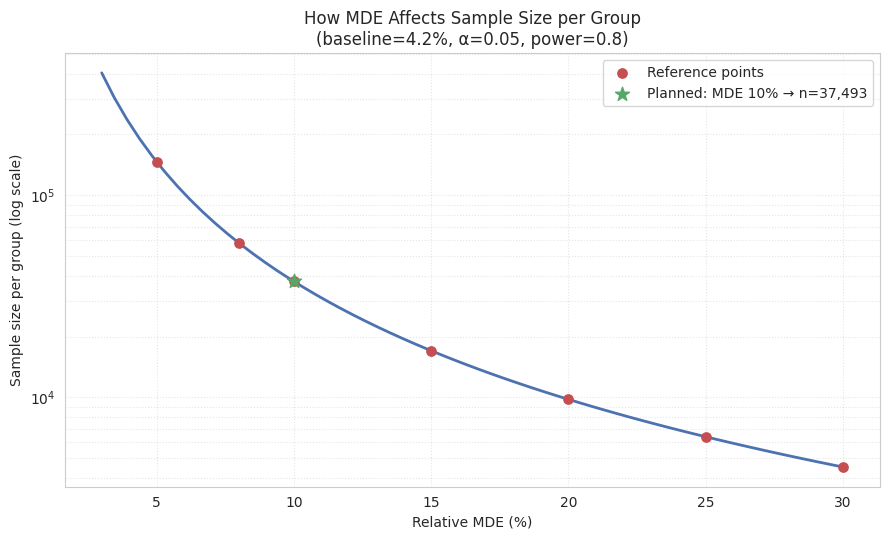

saved: 01_mde_vs_sample_size.png


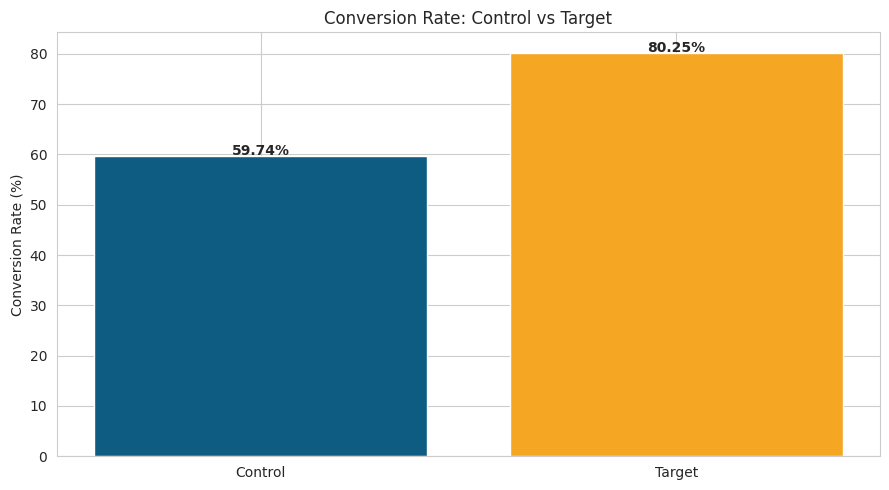

saved: 02_conversion_rate_by_group.png


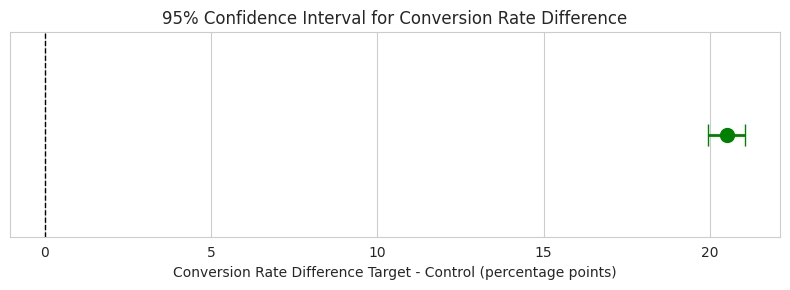

saved: 03_conversion_rate_ci.png


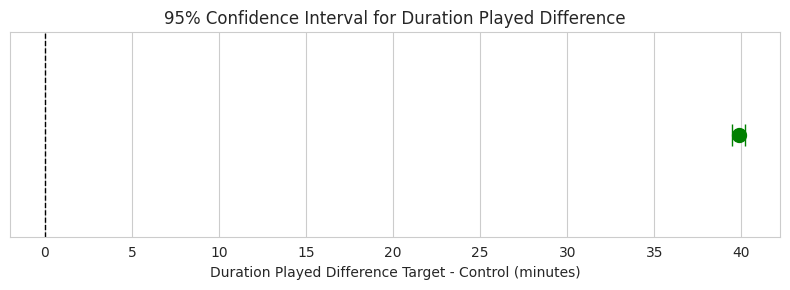

saved: 05_duration_played_ci.png


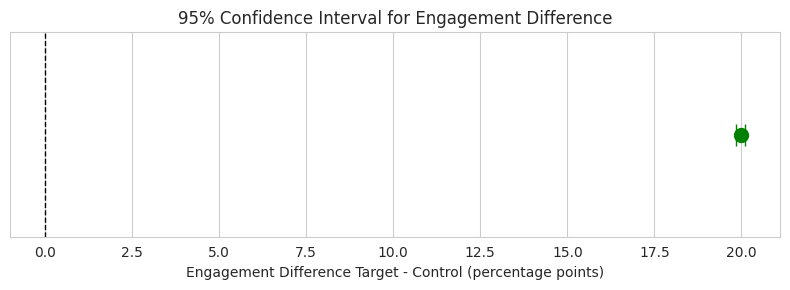

saved: 07_engagement_ci.png


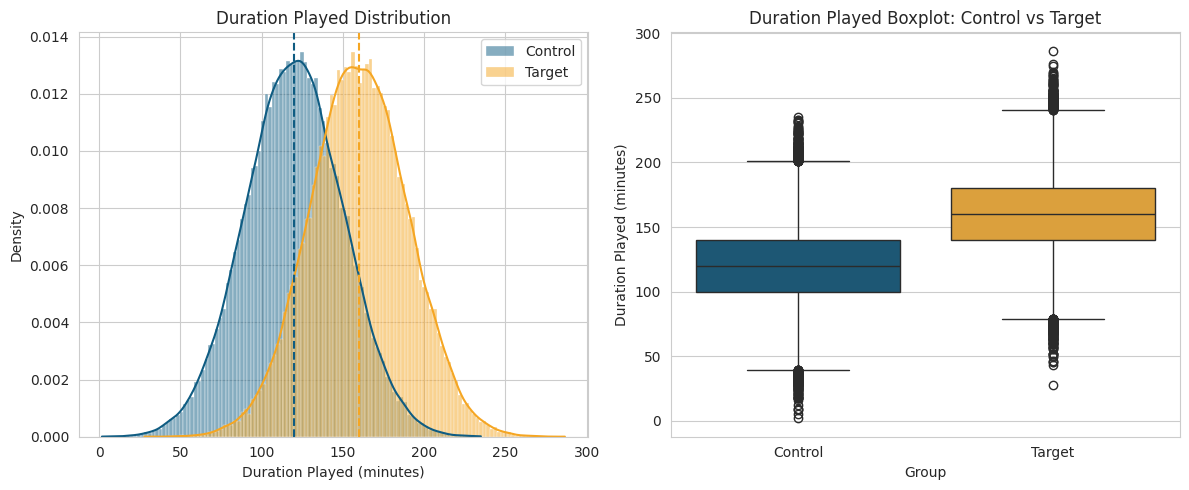

saved: 04_duration_played_distribution.png


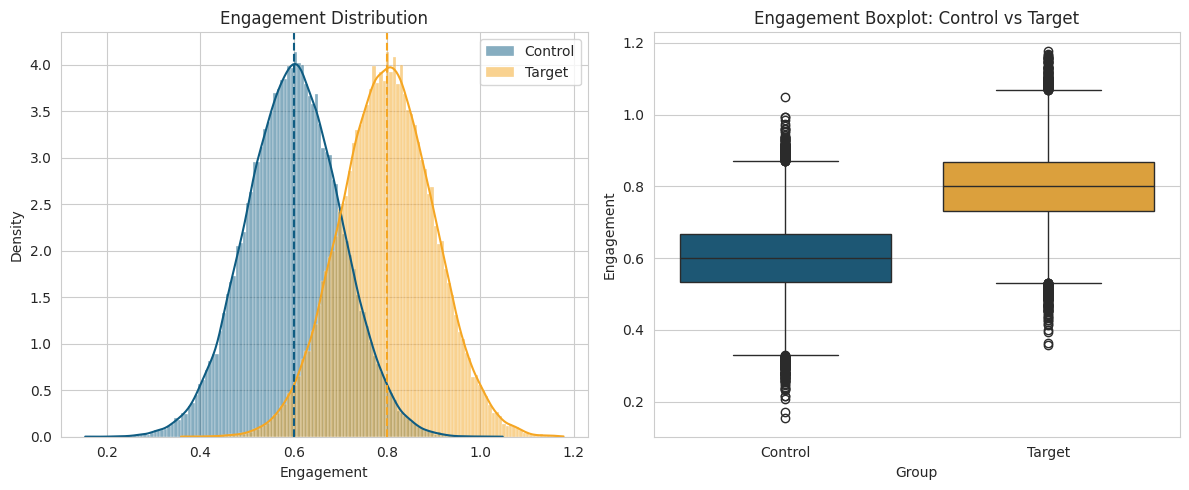

saved: 06_engagement_distribution.png


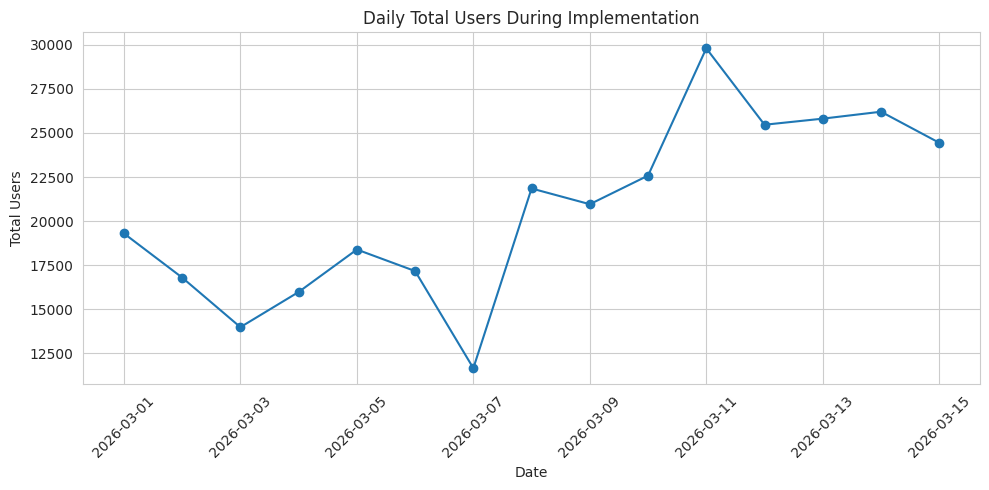

saved: 08_post_implementation_daily_users.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done: images.zip downloaded. Extract it and upload the PNGs to the images/ folder on GitHub.


In [26]:
# ==============================================================
# SAVE ALL CHARTS (English labels) -> /content/images + images.zip
# Paste this into ONE new cell at the END of the notebook and run it.
# Requirement: all previous cells have already been run (same runtime),
# because this cell reuses variables such as dfcamp_clean, summary, dfpost.
# If the runtime was restarted: Runtime > Run all first.
# ==============================================================
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

OUT_DIR = "/content/images"
os.makedirs(OUT_DIR, exist_ok=True)
sns.set_style("whitegrid")
COLORS = {"Control": "#0F5C82", "Target": "#F5A623"}


def save_fig(name):
    """Save the current figure as PNG, show it, then close it."""
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/{name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"saved: {name}.png")


# --------------------------------------------------------------
# 01. MDE vs sample size
# --------------------------------------------------------------
mde_fine = np.linspace(0.03, 0.30, 60)
n_fine = [sample_size_for_mde(baseline_rate, m, alpha, power_target)[2] for m in mde_fine]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(mde_fine * 100, n_fine, color="#4C72B0", linewidth=2, zorder=2)
ax.scatter(df_sensitivity["MDE (%)"], df_sensitivity["n per grup"],
           color="#C44E52", zorder=3, s=45, label="Reference points")
ax.scatter([mde_relative_planned * 100], [n_required_per_group],
           color="#55A868", zorder=4, s=110, marker="*",
           label=f"Planned: MDE {mde_relative_planned*100:.0f}% → n={n_required_per_group:,}")
ax.set_yscale("log")
ax.set_xlabel("Relative MDE (%)")
ax.set_ylabel("Sample size per group (log scale)")
ax.set_title("How MDE Affects Sample Size per Group\n"
             f"(baseline={baseline_rate*100:.1f}%, α={alpha}, power={power_target})")
ax.legend()
ax.grid(True, which="both", linestyle=":", alpha=0.5)
save_fig("01_mde_vs_sample_size")

# --------------------------------------------------------------
# 02. Conversion rate by group
# --------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))
rates = summary["conversion_rate"] * 100
bars = ax.bar(summary.index, rates, color=[COLORS[g] for g in summary.index])
ax.set_ylabel("Conversion Rate (%)")
ax.set_title("Conversion Rate: Control vs Target")
for bar, val in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.05, f"{val:.2f}%",
            ha="center", fontweight="bold")
save_fig("02_conversion_rate_by_group")


# --------------------------------------------------------------
# 03 / 05 / 07. Confidence interval of the difference (one helper)
# --------------------------------------------------------------
def ci_chart(diff, lower, upper, xlabel, title, name):
    fig, ax = plt.subplots(figsize=(8, 3))
    color = "green" if lower > 0 else ("red" if upper < 0 else "gray")
    ax.errorbar(x=[diff], y=[0], xerr=[[diff - lower], [upper - diff]],
                fmt="o", color=color, markersize=10, capsize=8, linewidth=2)
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_yticks([])
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    save_fig(name)


ci_chart(diff * 100, ci_diff_lower * 100, ci_diff_upper * 100,
         "Conversion Rate Difference Target - Control (percentage points)",
         "95% Confidence Interval for Conversion Rate Difference",
         "03_conversion_rate_ci")

ci_chart(diff_dur, ci_diff_lower_dur, ci_diff_upper_dur,
         "Duration Played Difference Target - Control (minutes)",
         "95% Confidence Interval for Duration Played Difference",
         "05_duration_played_ci")

ci_chart(diff_eng * 100, ci_diff_lower_eng * 100, ci_diff_upper_eng * 100,
         "Engagement Difference Target - Control (percentage points)",
         "95% Confidence Interval for Engagement Difference",
         "07_engagement_ci")


# --------------------------------------------------------------
# 04 / 06. Distribution + boxplot (Duration Played, Engagement)
# --------------------------------------------------------------
def dist_chart(column, control, target, unit_label, name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.histplot(control, color=COLORS["Control"], label="Control", kde=True,
                 stat="density", alpha=0.5, ax=axes[0])
    sns.histplot(target, color=COLORS["Target"], label="Target", kde=True,
                 stat="density", alpha=0.5, ax=axes[0])
    axes[0].axvline(control.mean(), color=COLORS["Control"], linestyle="--", linewidth=1.5)
    axes[0].axvline(target.mean(), color=COLORS["Target"], linestyle="--", linewidth=1.5)
    axes[0].set_xlabel(f"{column}{unit_label}")
    axes[0].set_title(f"{column} Distribution")
    axes[0].legend()

    # cleaned data (the 2 negative Duration Played rows are excluded)
    sns.boxplot(x="Group", y=column, hue="Group", data=dfcamp_clean,
                palette=COLORS, legend=False, ax=axes[1])
    axes[1].set_title(f"{column} Boxplot: Control vs Target")
    axes[1].set_ylabel(f"{column}{unit_label}")
    save_fig(name)


dist_chart("Duration Played", control_duration, target_duration,
           " (minutes)", "04_duration_played_distribution")
dist_chart("Engagement", control_engagement, target_engagement,
           "", "06_engagement_distribution")

# --------------------------------------------------------------
# 08. Daily users after implementation
# --------------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(dfpost["Date"], dfpost["Total Users"], marker="o")
plt.title("Daily Total Users During Implementation")
plt.xlabel("Date")
plt.ylabel("Total Users")
plt.xticks(rotation=45)
save_fig("08_post_implementation_daily_users")

# --------------------------------------------------------------
# Zip everything and download
# --------------------------------------------------------------
shutil.make_archive("/content/images", "zip", OUT_DIR)
files.download("/content/images.zip")
print("Done: images.zip downloaded. Extract it and upload the PNGs to the images/ folder on GitHub.")